# Grid Network Analysis - Week 2, Task 2.2: Geographic and Geospatial Analysis

**Scope**: this notebook covers Part A Task 2.2 (Geographic and Geospatial
Analysis) only. Task 2.3 (Business Intelligence) and the dashboard (Week 3)
are not included in this pass.

Builds the interactive Folium map, independently verifies line distances
with `geopy`'s geodesic formula, categorizes lines by length, analyses
regional connectivity density, flags possible geographic coverage gaps, and
finds geographic clusters of substations.

All logic lives in `../src/geo.py` (unit tested in `../tests/test_geo.py`)
so this notebook only narrates and interprets results.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src.cleaning import load_raw, clean_and_validate
from src.geo import (
    build_folium_map, verify_line_distances, categorize_line_distances,
    find_geographic_clusters, regional_connectivity, geographic_gaps,
)

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")
CHARTS_DIR = OUTPUTS_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

utilities, substations, lines = load_raw(DATA_DIR)
utilities, substations, lines, _ = clean_and_validate(utilities, substations, lines)

## Interactive map (with Utility Territory layers)

Substations are colored by voltage tier by default. Each utility also gets
its own toggleable "Territory" layer (off by default - switch it on via the
layer control) showing only the lines that utility operates, so you can see
ECG's footprint versus GRIDCo's versus NEDCo's independently.

In [2]:
grid_map = build_folium_map(substations, lines, utilities=utilities)
grid_map.save(str(OUTPUTS_DIR / "substation_map.html"))
grid_map

## Distance verification

Each line's `Length (km)` was originally derived from the haversine formula
in `generate_data.py`. Here we independently recompute it using `geopy`'s
geodesic formula (which accounts for the Earth's actual shape, not just a
perfect sphere) as a data-quality sanity check.

In [3]:
distance_check = verify_line_distances(substations, lines)
print("Largest differences between recorded and recomputed distance:")
distance_check.reindex(distance_check["Difference (km)"].abs().sort_values(ascending=False).index).head(10)

Largest differences between recorded and recomputed distance:


,Line ID,Source Substation,Destination Substation,Length (km),Geodesic Distance (km),Difference (km),Difference (%)
44,45,Ho Substation,Sunyani Substation,367.7,319.9,47.8,14.9
45,46,Sunyani Substation,Tamale Substation,324.3,281.1,43.2,15.4
49,50,Bolgatanga Interconnection,Bobo-Dioulasso Hub,426.0,387.7,38.3,9.9
40,41,Kumasi Central Substation,Takoradi Substation,228.3,197.5,30.8,15.6
39,40,Achimota Substation,Kumasi Central Substation,225.4,195.8,29.6,15.1
47,48,Bolgatanga Substation,Wa Substation,227.0,197.4,29.6,15.0
34,35,Hohoe Substation,Sogakope Substation,152.5,127.0,25.5,20.1
42,43,Cape Coast Substation,Koforidua Substation,178.8,155.1,23.7,15.3
46,47,Tamale Substation,Bolgatanga Substation,175.4,151.7,23.7,15.6
27,28,Koforidua Substation,Nkawkaw Substation,98.0,76.0,22.0,28.9


In [4]:
print("Distribution of the recorded-vs-recomputed difference (%):")
distance_check["Difference (%)"].describe()

Distribution of the recorded-vs-recomputed difference (%):


count    55.000000
mean     16.740000
std       6.805733
min       6.800000
25%      10.450000
50%      15.300000
75%      21.550000
max      29.800000
Name: Difference (%), dtype: float64

## Distance Analysis: Short / Medium / Long transmission runs

Lines are bucketed as Short (<=20 km), Medium (20-100 km), or Long
(>=100 km), then cross-tabulated against voltage tier - the expectation
being that short lines skew toward low-voltage local distribution and long
lines skew toward high-voltage transmission backbone.

In [5]:
categorized, counts, by_voltage = categorize_line_distances(lines)
counts

distance_category
Medium    28
Long      18
Short      9
Name: count, dtype: int64

In [6]:
by_voltage

Voltage (kV),11,33,69,161,330
distance_category,,,,,
Long,4,0,1,0,13
Medium,8,7,8,2,3
Short,2,1,0,5,1


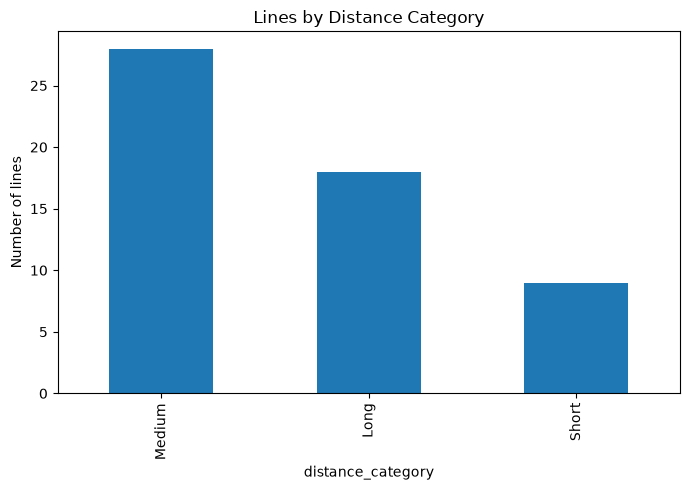

In [7]:
counts.plot(kind="bar", figsize=(7, 5), title="Lines by Distance Category")
plt.ylabel("Number of lines")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "distance_categories.png")
plt.show()

## Regional Connectivity

Substation density (count and total capacity) per region, plus how many
lines stay within a single region ("intra-regional") versus cross a region
boundary - a first look at how tightly-knit each region's own infrastructure
is versus how much it depends on inter-regional links.

In [8]:
connectivity = regional_connectivity(substations, lines)
print(f"Intra-regional lines: {connectivity['intra_regional_lines']}")
print(f"Cross-regional lines: {connectivity['cross_regional_lines']}")
connectivity["density_by_region"]

Intra-regional lines: 39
Cross-regional lines: 16


,Region,substation_count,total_capacity_mva
9,Greater Accra,6,520.2
0,Ashanti,5,1099.6
5,Central,4,316.2
8,Eastern,4,828.5
16,Volta,4,470.3
17,Western,4,323.0
2,Bono,3,252.6
11,Northern,3,155.6
14,Upper East,2,520.7
3,Burkina Faso,1,445.9


## Geographic Gaps (proxy)

Regions with substation counts below the cross-region median. Without real
population or land-area data, substation count relative to other regions is
the best available proxy signal for "possibly underserved" - this is
explicitly a structural proxy, not a demand-based needs assessment.

In [9]:
gaps = geographic_gaps(substations)
gaps

,Region,substation_count,below_median_density
1,Benin,1,True
3,Burkina Faso,1,True
4,Burkina Faso border,1,True
15,Upper West,1,True
6,Cote d'Ivoire,1,True
7,Cote d'Ivoire border,1,True
13,Togo border,1,True
10,Guinea,1,True
12,Togo,1,True
14,Upper East,2,False


## Substation Clustering

Groups substations into geographic clusters using proximity: any two
substations within a chosen radius are linked, and connected groups of that
proximity graph become clusters. This uses the same "connected components"
idea as Task 2.1's network analysis, but applied to physical distance
instead of electrical connections.

In [10]:
clustered, clusters = find_geographic_clusters(substations, radius_km=25)
print(f"Number of geographic clusters (25 km radius): {len(clusters)}")
print(f"Cluster sizes: {sorted((len(c) for c in clusters), reverse=True)}")

Number of geographic clusters (25 km radius): 32
Cluster sizes: [7, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
# Which clusters contain the highest-capacity substations?
high_capacity_threshold = substations["Capacity (MVA)"].quantile(0.75)
high_capacity_subs = clustered[clustered["Capacity (MVA)"] >= high_capacity_threshold]
high_capacity_subs.groupby("geo_cluster")[["Name", "Region", "Capacity (MVA)"]].apply(
    lambda g: list(zip(g["Name"], g["Region"], g["Capacity (MVA)"]))
)

geo_cluster
1                  [(Ejisu Substation, Ashanti, 355.9)]
3                  [(Suhum Substation, Eastern, 339.0)]
6          [(Aflao Border Station, Togo border, 423.2)]
9                [(Konongo Substation, Ashanti, 285.2)]
15               [(Nkawkaw Substation, Eastern, 389.2)]
16                      [(Ho Substation, Volta, 382.1)]
23         [(Bolgatanga Substation, Upper East, 325.9)]
27    [(Elubo Border Station, Cote d'Ivoire border, ...
28           [(Cotonou Transmission Hub, Benin, 487.6)]
29    [(Abidjan Transmission Hub, Cote d'Ivoire, 262...
30          [(Bobo-Dioulasso Hub, Burkina Faso, 445.9)]
dtype: object

## Regional analysis report - summary of key findings

(Task 2.2 deliverable: a short written report. Filled in with whatever this
notebook's own outputs above actually show when executed - see the printed
cells above for the exact numbers; this section only interprets them.)

- The map's per-utility "Territory" layers make it visually obvious which
  parts of the country each utility actually operates in, versus just
  reading utility/line counts as numbers.
- The distance-verification step is a data-quality check on the generator's
  own haversine-based lengths - large discrepancies would indicate a bug in
  how a line's length was derived, not a real-world measurement error.
- The Short/Medium/Long breakdown, cross-tabbed with voltage, shows whether
  the expected pattern (short lines are low-voltage/local, long lines are
  high-voltage/backbone) actually holds in this generated network.
- Regional connectivity and the geographic-gaps proxy give a first-pass
  read on which regions are relatively infrastructure-dense versus sparse -
  useful context heading into Task 2.3's business-intelligence work
  (explicitly out of scope for this notebook).
- Substation clustering identifies physically co-located groups of
  stations, independent of whether they're electrically connected -
  worth comparing against Task 2.1's community detection (electrical
  clusters) to see how well geography and network topology line up.

## Notes and limitations

- All figures above are derived from a **synthetic**, seeded dataset - see
  `01_data_cleaning_and_eda.ipynb` and
  `../../docs/architecture-diagrams/grid-analysis-data-dictionary.md` for
  the underlying data's description and limitations.
- The geographic-gaps proxy and the clustering radius are both simplified
  stand-ins chosen for this coursework dataset, not calibrated against any
  real demand, population, or engineering standard.
- Business intelligence (Task 2.3) and the interactive dashboard (Week 3)
  are not part of this notebook.